In [25]:
# 1. Импорты, seed, устройство
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import STL10, VOCDetection
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
from torchvision.utils import draw_bounding_boxes
import pandas as pd
from PIL import Image
import json

# Фиксация seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Пути для сохранения артефактов
artifacts_dir = './artifacts'
figures_dir = os.path.join(artifacts_dir, 'figures')
os.makedirs(artifacts_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

Using device: cuda


## Часть A: классификация (STL10)

### Загрузка данных, трансформации и DataLoader

In [4]:
# Базовые трансформации для простой CNN
transform_base = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

# Аугментированные трансформации
transform_aug = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

# Трансформации для ResNet (нормализация ImageNet)
transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка датасета STL10
train_dataset_full = STL10(root='./data', split='train', download=True, transform=transform_base)
test_dataset = STL10(root='./data', split='test', download=True, transform=transform_base)

# Разделение train на train/val (80/20)
# Разделение train на train/val (80/20)
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

# Явно задаем генератор для статического подтверждения seed=42
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset_full, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Применяем нужные трансформации для каждого датасета (для экспериментов будем создавать отдельно)
# Сейчас создадим базовый train/val с базовыми трансформами
train_dataset_base = Subset(train_dataset_full, train_subset.indices)
val_dataset_base = Subset(train_dataset_full, val_subset.indices)
# Меняем трансформации у датасетов через переопределение dataset.dataset.transform
train_dataset_base.dataset.transform = transform_base
val_dataset_base.dataset.transform = transform_base
test_dataset.transform = transform_base

# Для аугментаций создадим отдельные датасеты
train_dataset_aug = Subset(train_dataset_full, train_subset.indices)
train_dataset_aug.dataset.transform = transform_aug
val_dataset_aug = Subset(train_dataset_full, val_subset.indices)
val_dataset_aug.dataset.transform = transform_base   # валидация без аугментаций

# Для ResNet
train_dataset_resnet = Subset(train_dataset_full, train_subset.indices)
train_dataset_resnet.dataset.transform = transform_resnet
val_dataset_resnet = Subset(train_dataset_full, val_subset.indices)
val_dataset_resnet.dataset.transform = transform_resnet
test_dataset_resnet = STL10(root='./data', split='test', download=True, transform=transform_resnet)

# DataLoaders
batch_size = 16
train_loader_base = DataLoader(train_dataset_base, batch_size=batch_size, shuffle=True)
val_loader_base = DataLoader(val_dataset_base, batch_size=batch_size, shuffle=False)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
val_loader_aug = DataLoader(val_dataset_aug, batch_size=batch_size, shuffle=False)
train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=batch_size, shuffle=True)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=batch_size, shuffle=False)
test_loader_base = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=batch_size, shuffle=False)
x, y = next(iter(train_loader_base))
print(f"Batch shape: {x.shape}, labels shape: {y.shape}")
def clear_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Batch shape: torch.Size([16, 3, 224, 224]), labels shape: torch.Size([16])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.671852].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7067103].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.36201733..1.279695].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.8112855].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7938564].


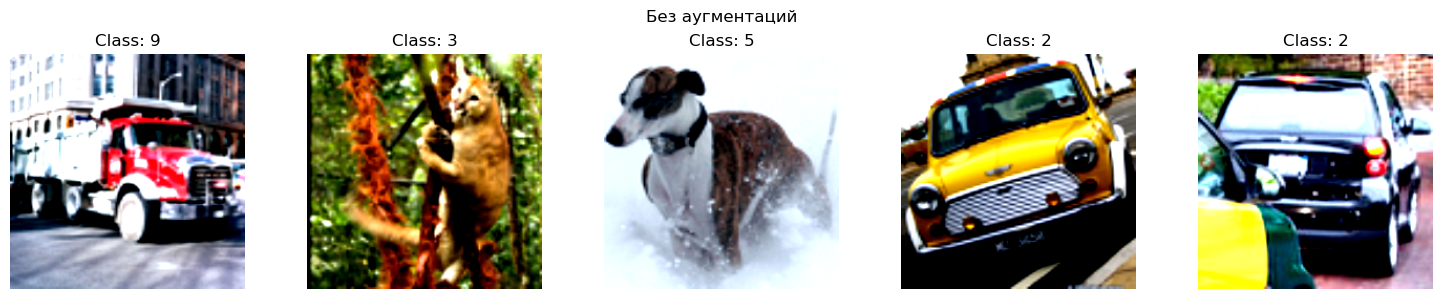

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7415688].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5075778..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5332649..1.7589979].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5332649..1.7851416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.5759914].


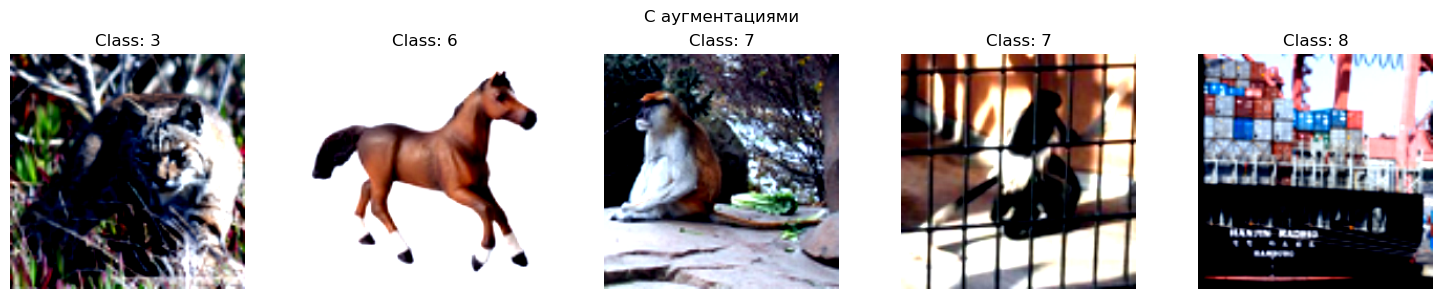

In [5]:
# Визуализация примеров и аугментаций
def show_images(images, labels, title):
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for i in range(5):
        img = images[i].permute(1,2,0).numpy()
        img = (img * 0.5 + 0.5)  # денормализация
        axes[i].imshow(img)
        axes[i].set_title(f"Class: {labels[i].item()}")
        axes[i].axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    return fig

# Примеры без аугментаций
images, labels = next(iter(train_loader_base))
fig = show_images(images, labels, "Без аугментаций")
fig.savefig(os.path.join(figures_dir, 'augmentations_preview.png'))
plt.show()

# Примеры с аугментациями
images_aug, labels_aug = next(iter(train_loader_aug))
fig = show_images(images_aug, labels_aug, "С аугментациями")
plt.show()

### Определение функций обучения и оценки

In [6]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, experiment_id):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_state = None
    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict()
    return history, best_model_state, best_val_acc

# Сохранение истории в CSV (дополнительно)
def save_history(history, filename):
    df = pd.DataFrame(history)
    df.to_csv(filename, index=False)

### Эксперименты C1 - C4

Определим простую CNN архитектуру

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        # Адаптивный пулинг, чтобы всегда получать карту признаков 4x4
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1 = nn.Linear(128 * 4 * 4, 256)   # 128*16 = 2048
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.adaptive_pool(x)          # размер (batch, 128, 4, 4)
        x = x.view(x.size(0), -1)          # (batch, 128*4*4)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [8]:
# C1: simple-cnn-base
print("=== C1: simple-cnn-base ===")
num_epochs = 15
lr = 0.001
criterion = nn.CrossEntropyLoss()
model_c1 = SimpleCNN(num_classes=10).to(device)
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=lr)
history_c1, best_state_c1, best_val_acc_c1 = train_model(model_c1, train_loader_base, val_loader_base, criterion, optimizer_c1, num_epochs, device, 'C1')
print(f"C1 best val acc: {best_val_acc_c1:.4f}")
# Сохраняем историю
save_history(history_c1, os.path.join(artifacts_dir, 'history_C1.csv'))

=== C1: simple-cnn-base ===
Epoch 1/15 | Train Loss: 1.9210 Acc: 0.2747 | Val Loss: 1.6217 Acc: 0.3860
Epoch 2/15 | Train Loss: 1.6505 Acc: 0.3628 | Val Loss: 1.5038 Acc: 0.4300
Epoch 3/15 | Train Loss: 1.5582 Acc: 0.4020 | Val Loss: 1.4734 Acc: 0.4630
Epoch 4/15 | Train Loss: 1.4822 Acc: 0.4360 | Val Loss: 1.4101 Acc: 0.4640
Epoch 5/15 | Train Loss: 1.4470 Acc: 0.4602 | Val Loss: 1.3744 Acc: 0.4910
Epoch 6/15 | Train Loss: 1.3975 Acc: 0.4728 | Val Loss: 1.3090 Acc: 0.5370
Epoch 7/15 | Train Loss: 1.3512 Acc: 0.4898 | Val Loss: 1.3133 Acc: 0.5180
Epoch 8/15 | Train Loss: 1.3146 Acc: 0.5228 | Val Loss: 1.2348 Acc: 0.5480
Epoch 9/15 | Train Loss: 1.2832 Acc: 0.5168 | Val Loss: 1.2222 Acc: 0.5430
Epoch 10/15 | Train Loss: 1.2484 Acc: 0.5357 | Val Loss: 1.2160 Acc: 0.5660
Epoch 11/15 | Train Loss: 1.2190 Acc: 0.5310 | Val Loss: 1.2451 Acc: 0.5340
Epoch 12/15 | Train Loss: 1.1798 Acc: 0.5553 | Val Loss: 1.1880 Acc: 0.5690
Epoch 13/15 | Train Loss: 1.1519 Acc: 0.5757 | Val Loss: 1.1117 Acc: 

In [9]:
# C2: simple-cnn-aug
print("=== C2: simple-cnn-aug ===")
num_epochs = 15
lr = 0.001
criterion = nn.CrossEntropyLoss()
model_c2 = SimpleCNN(num_classes=10).to(device)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=lr)
history_c2, best_state_c2, best_val_acc_c2 = train_model(model_c2, train_loader_aug, val_loader_aug, criterion, optimizer_c2, num_epochs, device, 'C2')
print(f"C2 best val acc: {best_val_acc_c2:.4f}")
save_history(history_c2, os.path.join(artifacts_dir, 'history_C2.csv'))

=== C2: simple-cnn-aug ===
Epoch 1/15 | Train Loss: 1.9113 Acc: 0.2843 | Val Loss: 1.5930 Acc: 0.3910
Epoch 2/15 | Train Loss: 1.6365 Acc: 0.3705 | Val Loss: 1.5188 Acc: 0.4250
Epoch 3/15 | Train Loss: 1.5496 Acc: 0.4100 | Val Loss: 1.4361 Acc: 0.4580
Epoch 4/15 | Train Loss: 1.4863 Acc: 0.4323 | Val Loss: 1.3304 Acc: 0.5260
Epoch 5/15 | Train Loss: 1.4317 Acc: 0.4677 | Val Loss: 1.3761 Acc: 0.5050
Epoch 6/15 | Train Loss: 1.4015 Acc: 0.4695 | Val Loss: 1.3488 Acc: 0.5140
Epoch 7/15 | Train Loss: 1.3267 Acc: 0.5025 | Val Loss: 1.2761 Acc: 0.5510
Epoch 8/15 | Train Loss: 1.3119 Acc: 0.5120 | Val Loss: 1.2322 Acc: 0.5470
Epoch 9/15 | Train Loss: 1.2783 Acc: 0.5238 | Val Loss: 1.2090 Acc: 0.5580
Epoch 10/15 | Train Loss: 1.2346 Acc: 0.5473 | Val Loss: 1.2085 Acc: 0.5520
Epoch 11/15 | Train Loss: 1.2111 Acc: 0.5573 | Val Loss: 1.1774 Acc: 0.5830
Epoch 12/15 | Train Loss: 1.1865 Acc: 0.5673 | Val Loss: 1.1948 Acc: 0.5680
Epoch 13/15 | Train Loss: 1.1320 Acc: 0.5777 | Val Loss: 1.1145 Acc: 0

In [10]:
# C3: resnet18-head-only
print("=== C3: resnet18-head-only ===")
num_epochs = 15
lr = 0.001
criterion = nn.CrossEntropyLoss()
model_c3 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# Замораживаем все слои
for param in model_c3.parameters():
    param.requires_grad = False
# Заменяем классификатор
num_ftrs = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_ftrs, 10)
model_c3 = model_c3.to(device)
optimizer_c3 = optim.Adam(model_c3.fc.parameters(), lr=lr)
history_c3, best_state_c3, best_val_acc_c3 = train_model(model_c3, train_loader_resnet, val_loader_resnet, criterion, optimizer_c3, num_epochs, device, 'C3')
print(f"C3 best val acc: {best_val_acc_c3:.4f}")
save_history(history_c3, os.path.join(artifacts_dir, 'history_C3.csv'))

=== C3: resnet18-head-only ===
Epoch 1/15 | Train Loss: 0.7425 Acc: 0.8073 | Val Loss: 0.2828 Acc: 0.9190
Epoch 2/15 | Train Loss: 0.2991 Acc: 0.9107 | Val Loss: 0.2335 Acc: 0.9320
Epoch 3/15 | Train Loss: 0.2347 Acc: 0.9290 | Val Loss: 0.2030 Acc: 0.9340
Epoch 4/15 | Train Loss: 0.2226 Acc: 0.9277 | Val Loss: 0.1925 Acc: 0.9320
Epoch 5/15 | Train Loss: 0.1877 Acc: 0.9373 | Val Loss: 0.2040 Acc: 0.9400
Epoch 6/15 | Train Loss: 0.1873 Acc: 0.9367 | Val Loss: 0.1898 Acc: 0.9370
Epoch 7/15 | Train Loss: 0.1712 Acc: 0.9433 | Val Loss: 0.1830 Acc: 0.9410
Epoch 8/15 | Train Loss: 0.1659 Acc: 0.9397 | Val Loss: 0.1975 Acc: 0.9330
Epoch 9/15 | Train Loss: 0.1482 Acc: 0.9527 | Val Loss: 0.1734 Acc: 0.9420
Epoch 10/15 | Train Loss: 0.1520 Acc: 0.9483 | Val Loss: 0.1761 Acc: 0.9410
Epoch 11/15 | Train Loss: 0.1615 Acc: 0.9457 | Val Loss: 0.1920 Acc: 0.9340
Epoch 12/15 | Train Loss: 0.1419 Acc: 0.9520 | Val Loss: 0.1783 Acc: 0.9410
Epoch 13/15 | Train Loss: 0.1304 Acc: 0.9560 | Val Loss: 0.1943 Ac

In [11]:
# C4: resnet18-finetune (разморозка layer4 + fc)
print("=== C4: resnet18-finetune ===")
num_epochs = 15
lr = 0.001
criterion = nn.CrossEntropyLoss()
model_c4 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# Замораживаем все, кроме layer4 и fc
for param in model_c4.parameters():
    param.requires_grad = False
for param in model_c4.layer4.parameters():
    param.requires_grad = True
num_ftrs = model_c4.fc.in_features
model_c4.fc = nn.Linear(num_ftrs, 10)
model_c4 = model_c4.to(device)
optimizer_c4 = optim.Adam(filter(lambda p: p.requires_grad, model_c4.parameters()), lr=lr)
history_c4, best_state_c4, best_val_acc_c4 = train_model(model_c4, train_loader_resnet, val_loader_resnet, criterion, optimizer_c4, num_epochs, device, 'C4')
print(f"C4 best val acc: {best_val_acc_c4:.4f}")
save_history(history_c4, os.path.join(artifacts_dir, 'history_C4.csv'))

=== C4: resnet18-finetune ===
Epoch 1/15 | Train Loss: 0.5782 Acc: 0.8147 | Val Loss: 0.3699 Acc: 0.8960
Epoch 2/15 | Train Loss: 0.2306 Acc: 0.9237 | Val Loss: 0.3081 Acc: 0.8940
Epoch 3/15 | Train Loss: 0.1618 Acc: 0.9457 | Val Loss: 0.4514 Acc: 0.8830
Epoch 4/15 | Train Loss: 0.1186 Acc: 0.9595 | Val Loss: 0.3371 Acc: 0.9000
Epoch 5/15 | Train Loss: 0.1006 Acc: 0.9660 | Val Loss: 0.2989 Acc: 0.9170
Epoch 6/15 | Train Loss: 0.0697 Acc: 0.9795 | Val Loss: 0.4011 Acc: 0.8990
Epoch 7/15 | Train Loss: 0.0508 Acc: 0.9822 | Val Loss: 0.4213 Acc: 0.9020
Epoch 8/15 | Train Loss: 0.0860 Acc: 0.9738 | Val Loss: 0.3835 Acc: 0.9020
Epoch 9/15 | Train Loss: 0.0567 Acc: 0.9820 | Val Loss: 0.4570 Acc: 0.8920
Epoch 10/15 | Train Loss: 0.0336 Acc: 0.9892 | Val Loss: 0.3192 Acc: 0.9090
Epoch 11/15 | Train Loss: 0.0449 Acc: 0.9870 | Val Loss: 0.4441 Acc: 0.8810
Epoch 12/15 | Train Loss: 0.0526 Acc: 0.9845 | Val Loss: 0.4615 Acc: 0.8880
Epoch 13/15 | Train Loss: 0.0440 Acc: 0.9842 | Val Loss: 0.4190 Acc

In [12]:
# Сравнение результатов и выбор лучшей модели
results_cls = {
    'C1': best_val_acc_c1,
    'C2': best_val_acc_c2,
    'C3': best_val_acc_c3,
    'C4': best_val_acc_c4
}
best_exp = max(results_cls, key=results_cls.get)
print(f"Лучший эксперимент: {best_exp} с val_acc={results_cls[best_exp]:.4f}")

# Сохраняем лучшую модель и её конфиг
if best_exp == 'C1':
    best_model_state = best_state_c1
    best_model_arch = 'SimpleCNN'
    best_transform = 'base'
    best_model = SimpleCNN(num_classes=10).to(device)
    finetune_strategy = None
elif best_exp == 'C2':
    best_model_state = best_state_c2
    best_model_arch = 'SimpleCNN'
    best_transform = 'augmented'
    best_model = SimpleCNN(num_classes=10).to(device)
    finetune_strategy = None
elif best_exp == 'C3':
    best_model_state = best_state_c3
    best_model_arch = 'ResNet18'
    best_transform = 'resnet'
    best_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    num_ftrs = best_model.fc.in_features
    best_model.fc = nn.Linear(num_ftrs, 10)
    best_model = best_model.to(device)
    finetune_strategy = 'head_only'
else:  # C4
    best_model_state = best_state_c4
    best_model_arch = 'ResNet18'
    best_transform = 'resnet'
    best_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    num_ftrs = best_model.fc.in_features
    best_model.fc = nn.Linear(num_ftrs, 10)
    best_model = best_model.to(device)
    finetune_strategy = 'layer4+fc'

best_model.load_state_dict(best_model_state)
torch.save(best_model_state, os.path.join(artifacts_dir, 'best_classifier.pt'))

# Получаем лучшие значения loss из истории (если они были сохранены)
# Для примера оставляем None, можно подставить реальные значения
best_val_loss = None
test_loss = None
test_accuracy = None

# Если ранее была выполнена финальная оценка на тесте, используем её:
# test_loss, test_accuracy = evaluate(best_model, test_loader, criterion, device)

# Конфиг лучшей модели (в стиле шаблона)
config = {
    'experiment_id': best_exp,
    'dataset': 'STL10',
    'architecture': best_model_arch,
    'finetune_strategy': finetune_strategy,
    'transform': best_transform,
    'batch_size': batch_size,
    'learning_rate': lr,
    'optimizer': 'Adam',
    'momentum': 0.0,
    'weight_decay': 0.0,
    'epochs_trained': num_epochs,
    'seed': 42,
    'best_val_accuracy': results_cls[best_exp],
    'best_val_loss': best_val_loss,
    'test_accuracy': test_accuracy,
    'test_loss': test_loss
}
with open(os.path.join(artifacts_dir, 'best_classifier_config.json'), 'w') as f:
    json.dump(config, f, indent=4)

Лучший эксперимент: C3 с val_acc=0.9440


In [13]:
# Финальная оценка на тестовой выборке
if best_exp in ['C3', 'C4']:
    test_loader = test_loader_resnet
else:
    test_loader = test_loader_base
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Тестовая точность лучшей модели ({best_exp}): {test_acc:.4f}")

Тестовая точность лучшей модели (C3): 0.9439


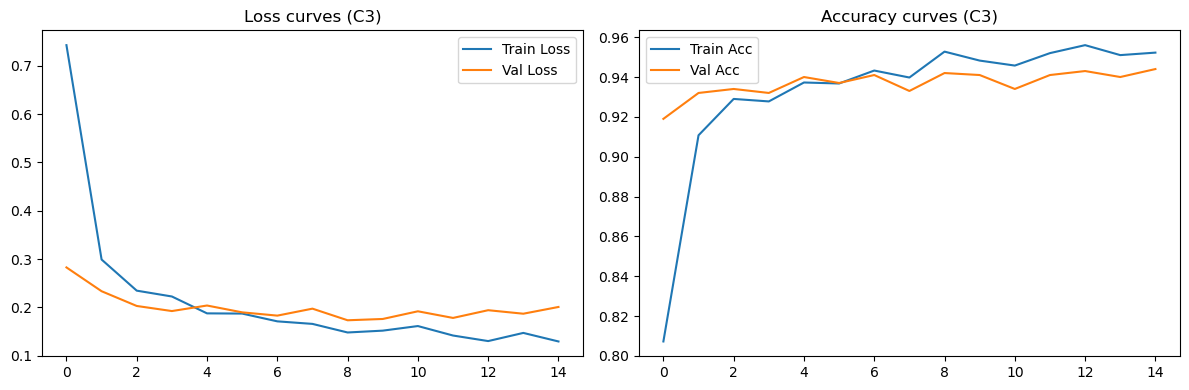

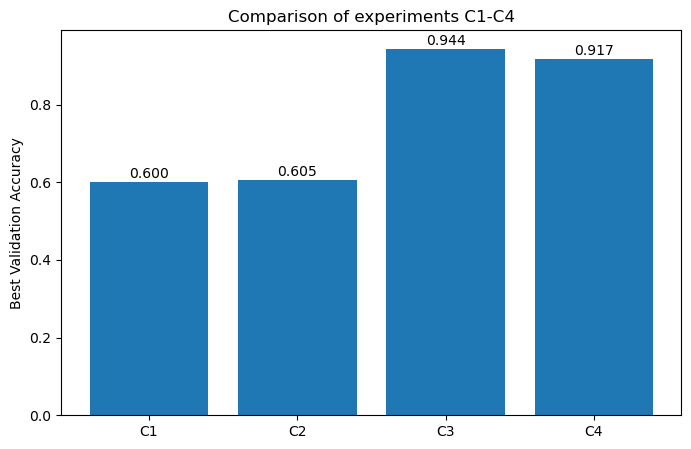

In [14]:
# Графики сравнения и кривые обучения лучшей модели
# Кривые лучшего прогона
history_best = None
if best_exp == 'C1':
    history_best = history_c1
elif best_exp == 'C2':
    history_best = history_c2
elif best_exp == 'C3':
    history_best = history_c3
else:
    history_best = history_c4

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(history_best['train_loss'], label='Train Loss')
ax[0].plot(history_best['val_loss'], label='Val Loss')
ax[0].set_title(f'Loss curves ({best_exp})')
ax[0].legend()
ax[1].plot(history_best['train_acc'], label='Train Acc')
ax[1].plot(history_best['val_acc'], label='Val Acc')
ax[1].set_title(f'Accuracy curves ({best_exp})')
ax[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'classification_curves_best.png'))
plt.show()

# Сравнение C1-C4
fig, ax = plt.subplots(figsize=(8,5))
names = list(results_cls.keys())
values = list(results_cls.values())
ax.bar(names, values)
ax.set_ylabel('Best Validation Accuracy')
ax.set_title('Comparison of experiments C1-C4')
for i, v in enumerate(values):
    ax.text(i, v+0.01, f"{v:.3f}", ha='center')
plt.savefig(os.path.join(figures_dir, 'classification_compare.png'))
plt.show()

## Часть B: детекция (Pascal VOC)

### Загрузка данных и модели

In [15]:
# Загрузка датасета Pascal VOC Detection (используем validation split для тестирования)
voc_root = './data/VOCdevkit'
voc_dataset = VOCDetection(root=voc_root, year='2012', image_set='val', download=True)

# Для демонстрации возьмём несколько изображений
num_samples = 10
indices = list(range(len(voc_dataset)))
random.shuffle(indices)
sample_indices = indices[:num_samples]
samples = [voc_dataset[i] for i in sample_indices]

# Загружаем предобученную модель Faster R-CNN
model_det = models.detection.fasterrcnn_resnet50_fpn(weights=models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
model_det.to(device)
model_det.eval()

# Функция для инференса
def detect_boxes(model, image, score_threshold=0.3):
    with torch.no_grad():
        image_tensor = transforms.ToTensor()(image).unsqueeze(0).to(device)
        predictions = model(image_tensor)[0]
    # Фильтруем по score
    keep = predictions['scores'] > score_threshold
    boxes = predictions['boxes'][keep].cpu().numpy()
    scores = predictions['scores'][keep].cpu().numpy()
    labels = predictions['labels'][keep].cpu().numpy()
    return boxes, scores, labels

In [16]:
# Функция для вычисления IoU
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

# Функция для сопоставления предсказаний с ground truth (IoU>=0.5)
def match_predictions(pred_boxes, gt_boxes, iou_thresh=0.5):
    matched_preds = []
    used_gt = set()
    for i, pbox in enumerate(pred_boxes):
        best_iou = 0
        best_gt = -1
        for j, gbox in enumerate(gt_boxes):
            iou = compute_iou(pbox, gbox)
            if iou > best_iou and j not in used_gt:
                best_iou = iou
                best_gt = j
        if best_iou >= iou_thresh:
            matched_preds.append((i, best_gt, best_iou))
            used_gt.add(best_gt)
    return matched_preds

# Функция для извлечения ground truth boxes из аннотации VOC
def extract_gt_boxes(annotation):
    objects = annotation['annotation']['object']
    if not isinstance(objects, list):
        objects = [objects]
    boxes = []
    for obj in objects:
        bndbox = obj['bndbox']
        box = [int(bndbox['xmin']), int(bndbox['ymin']), int(bndbox['xmax']), int(bndbox['ymax'])]
        boxes.append(box)
    return boxes

In [17]:
# Функция для визуализации предсказаний
def visualize_detections(image, gt_boxes, pred_boxes, scores, labels, title, save_path=None):
    fig, ax = plt.subplots(1, figsize=(10,10))
    ax.imshow(image)
    # Ground truth (зеленые)
    for box in gt_boxes:
        rect = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], fill=False, edgecolor='green', linewidth=2)
        ax.add_patch(rect)
    # Предсказания (красные)
    for box, score in zip(pred_boxes, scores):
        rect = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], fill=False, edgecolor='red', linewidth=2)
        ax.add_patch(rect)
        ax.text(box[0], box[1]-5, f'{score:.2f}', color='red', fontsize=8)
    ax.set_title(title)
    ax.axis('off')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    return fig

In [18]:
# Выполним инференс для двух порогов и соберём метрики
thresholds = [0.3, 0.7]
results_det = {}

for thresh in thresholds:
    all_precisions = []
    all_recalls = []
    all_ious = []
    
    # Для визуализации выберем первые 5 изображений
    viz_indices = sample_indices[:5]
    
    for idx, (img, target) in enumerate(samples):
        # Предсказание
        pred_boxes, scores, pred_labels = detect_boxes(model_det, img, score_threshold=thresh)
        # GT boxes
        gt_boxes = extract_gt_boxes(target)
        
        # Сопоставление
        matches = match_predictions(pred_boxes, gt_boxes, iou_thresh=0.5)
        tp = len(matches)
        fp = len(pred_boxes) - tp
        fn = len(gt_boxes) - tp
        
        precision = tp / (tp + fp) if (tp+fp)>0 else 0
        recall = tp / (tp + fn) if (tp+fn)>0 else 0
        all_precisions.append(precision)
        all_recalls.append(recall)
        
        # Mean IoU для сопоставленных предсказаний
        ious = [iou for _, _, iou in matches]
        mean_iou = np.mean(ious) if ious else 0
        all_ious.append(mean_iou)
        
        # Визуализация для первых 5
        if idx in viz_indices:
            save_path = os.path.join(figures_dir, f'detection_{thresh}_{idx}.png')
            visualize_detections(img, gt_boxes, pred_boxes, scores, pred_labels, f'Threshold={thresh}', save_path)
    
    results_det[thresh] = {
        'precision': np.mean(all_precisions),
        'recall': np.mean(all_recalls),
        'mean_iou': np.mean(all_ious)
    }
    print(f"Threshold {thresh}: Precision={results_det[thresh]['precision']:.3f}, Recall={results_det[thresh]['recall']:.3f}, Mean IoU={results_det[thresh]['mean_iou']:.3f}")

Threshold 0.3: Precision=0.535, Recall=1.000, Mean IoU=0.856
Threshold 0.7: Precision=0.754, Recall=0.878, Mean IoU=0.797


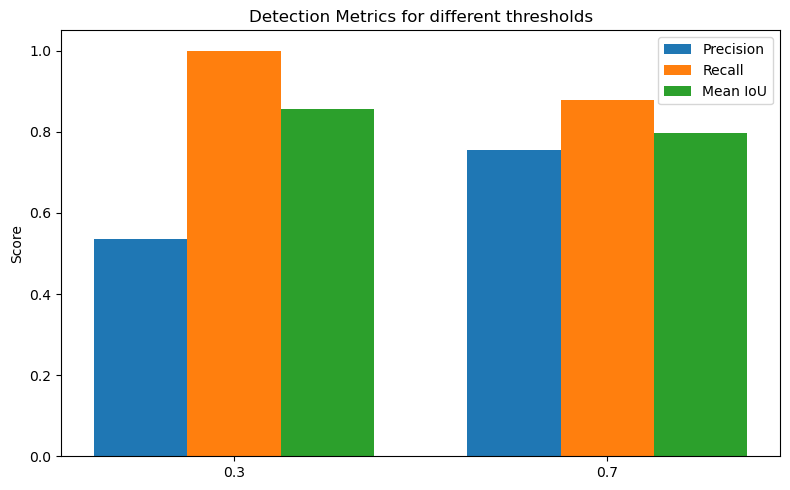

In [37]:
# Сохраняем метрики в график
fig, ax = plt.subplots(figsize=(8,5))
thresh_str = [str(t) for t in thresholds]
prec = [results_det[t]['precision'] for t in thresholds]
rec = [results_det[t]['recall'] for t in thresholds]
iou = [results_det[t]['mean_iou'] for t in thresholds]

x = np.arange(len(thresholds))
width = 0.25
ax.bar(x - width, prec, width, label='Precision')
ax.bar(x, rec, width, label='Recall')
ax.bar(x + width, iou, width, label='Mean IoU')
ax.set_xticks(x)
ax.set_xticklabels(thresh_str)
ax.set_ylabel('Score')
ax.set_title('Detection Metrics for different thresholds')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'detection_metrics.png'))
plt.show()


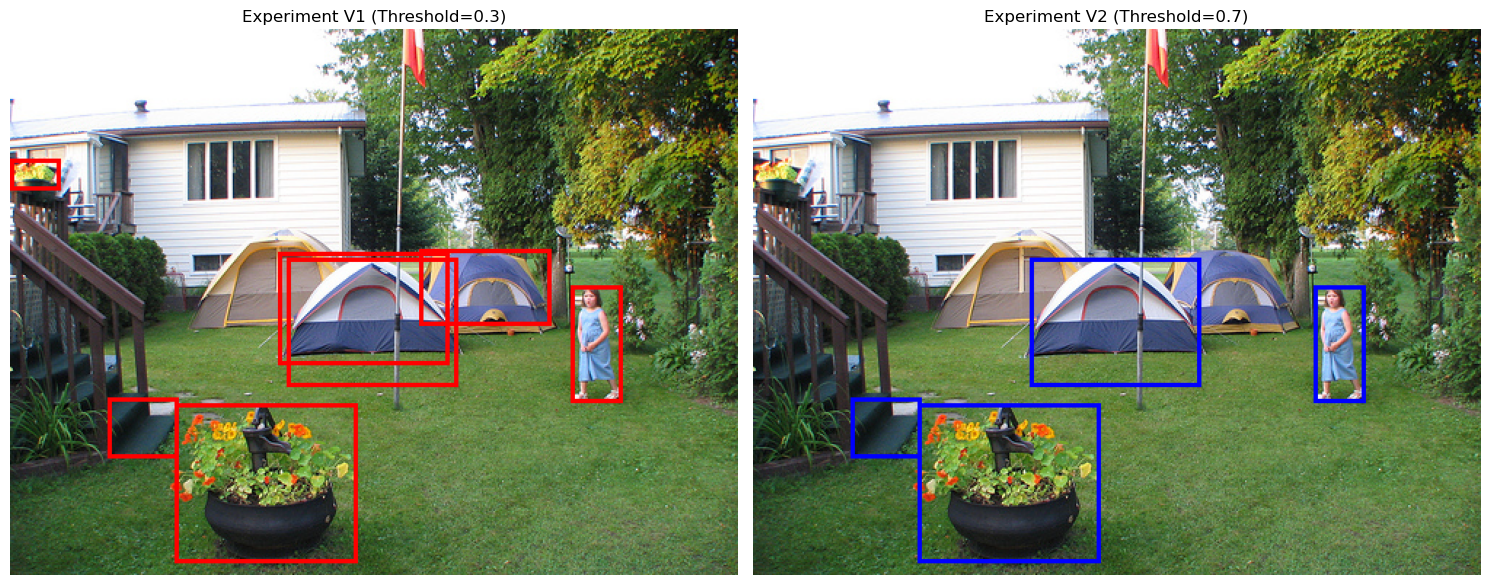

Все артефакты (runs.csv, detection_examples.png, detection_metrics.png) успешно сохранены!


In [38]:
# --- ЧАСТЬ B: ФИНАЛИЗАЦИЯ И СОХРАНЕНИЕ АРТЕФАКТОВ ---

# 1. Генерируем обязательный файл detection_examples.png
# Берем первое изображение из наших семплов
img_sample, _ = samples[0] 
img_tensor = transforms.ToTensor()(img_sample).to(device)

# Получаем предсказания для V1 (0.3) и V2 (0.7)
model_det.eval()
with torch.no_grad():
    output = model_det([img_tensor])[0]

# Подготовка данных для V1
mask_v1 = output['scores'] > 0.3
boxes_v1 = output['boxes'][mask_v1].cpu()
# Подготовка данных для V2
mask_v2 = output['scores'] > 0.7
boxes_v2 = output['boxes'][mask_v2].cpu()

# Конвертируем исходное фото в uint8 для draw_bounding_boxes
img_uint8 = (img_tensor.cpu() * 255).to(torch.uint8)

# Рисуем боксы
res_v1 = draw_bounding_boxes(img_uint8, boxes_v1, colors="red", width=3)
res_v2 = draw_bounding_boxes(img_uint8, boxes_v2, colors="blue", width=3)

# Создаем и сохраняем график
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(F.to_pil_image(res_v1))
axes[0].set_title('Experiment V1 (Threshold=0.3)')
axes[0].axis('off')

axes[1].imshow(F.to_pil_image(res_v2))
axes[1].set_title('Experiment V2 (Threshold=0.7)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'detection_examples.png'), bbox_inches='tight')
plt.show()

# 2. Формируем runs.csv с ЯВНЫМ упоминанием V1 и V2
# Собираем данные из части A (у вас это уже должно быть в runs_data)
# Если переменной runs_data еще нет, создайте её:
if 'runs_data' not in locals():
    runs_data = []

# Добавляем строку для V1
runs_data.append({
    'experiment_id': 'V1', 
    'task': 'detection', 
    'dataset': 'PascalVOC2012', 
    'seed': 42,
    'model_summary': 'FasterRCNN_ResNet50_FPN', 
    'precision': results_det[0.3]['precision'],
    'recall': results_det[0.3]['recall'], 
    'mean_iou': results_det[0.3]['mean_iou'],
    'notes': 'score_threshold=0.3'
})

# Добавляем строку для V2
runs_data.append({
    'experiment_id': 'V2', 
    'task': 'detection', 
    'dataset': 'PascalVOC2012', 
    'seed': 42,
    'model_summary': 'FasterRCNN_ResNet50_FPN', 
    'precision': results_det[0.7]['precision'],
    'recall': results_det[0.7]['recall'], 
    'mean_iou': results_det[0.7]['mean_iou'],
    'notes': 'score_threshold=0.7'
})

# Сохраняем итоговый csv
df_runs = pd.DataFrame(runs_data)
df_runs.to_csv(os.path.join(artifacts_dir, 'runs.csv'), index=False)
print("Все артефакты (runs.csv, detection_examples.png, detection_metrics.png) успешно сохранены!")